In [2]:
print("""
@File         : comparing_the_best_hitter_in_baseball_across_years.ipynb
@Author(s)    : Stephen CUI
@LastEditor(s): Stephen CUI
@CreatedTime  : 2025-01-05 14:27:58
@Email        : cuixuanstephen@gmail.com
@Description  : 比较历年棒球界最佳击球手
""")


@File         : comparing_the_best_hitter_in_baseball_across_years.ipynb
@Author(s)    : Stephen CUI
@LastEditor(s): Stephen CUI
@CreatedTime  : 2025-01-05 14:27:58
@Email        : cuixuanstephen@gmail.com
@Description  : 比较历年棒球界最佳击球手



In [3]:
import pandas as pd

In [4]:
df = pd.read_parquet('../DATA/mlb_batting_lines.parquet')

df

,year,game,starttime,visiting_team,home_team,id,side,pos,seq,ab,...,sh,sf,hpb,bb,ibb,k,sb,cs,gidp,int
0,2015,ANA201504100,7:12PM,KCA,ANA,escoa003,0,1,1,3,...,1,0,0,1,0,0,0,0,0,0
1,2015,ANA201504100,7:12PM,KCA,ANA,mousm001,0,2,1,3,...,0,0,2,0,0,0,0,0,0,0
2,2015,ANA201504100,7:12PM,KCA,ANA,cainl001,0,3,1,4,...,0,0,0,1,0,2,0,0,0,0
3,2015,ANA201504100,7:12PM,KCA,ANA,hosme001,0,4,1,5,...,0,0,0,0,0,1,0,0,0,0
4,2015,ANA201504100,7:12PM,KCA,ANA,morak001,0,5,1,5,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1630995,2013,WAS201309222,7:06PM,MIA,WAS,lombs002,1,9,2,1,...,0,0,0,0,0,0,0,0,0,0
1630996,2013,WAS201309222,7:06PM,MIA,WAS,stamc001,1,9,3,0,...,0,0,0,0,0,0,0,0,0,0
1630997,2013,WAS201309222,7:06PM,MIA,WAS,clipt001,1,9,4,0,...,0,0,0,0,0,0,0,0,0,0
1630998,2013,WAS201309222,7:06PM,MIA,WAS,tracc001,1,9,5,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
bal = df[df['game'] == "BAL201504100"]
bal.head()

,year,game,starttime,visiting_team,home_team,id,side,pos,seq,ab,...,sh,sf,hpb,bb,ibb,k,sb,cs,gidp,int
2383,2015,BAL201504100,3:11PM,TOR,BAL,reyej001,0,1,1,5,...,0,1,0,0,0,1,0,0,0,0
2384,2015,BAL201504100,3:11PM,TOR,BAL,pompd001,0,2,1,6,...,0,0,0,0,0,0,0,0,0,0
2385,2015,BAL201504100,3:11PM,TOR,BAL,bautj002,0,3,1,3,...,0,0,0,1,0,0,0,0,0,0
2386,2015,BAL201504100,3:11PM,TOR,BAL,tolls001,0,3,2,1,...,0,0,0,0,0,1,0,0,0,0
2387,2015,BAL201504100,3:11PM,TOR,BAL,encae001,0,4,1,4,...,0,1,0,0,0,2,0,0,0,0


In [6]:
bal[['ab', 'h', 'hr']].sum()

ab    75
h     29
hr     2
dtype: Int32

In [8]:
df.groupby(['year', 'id']).agg(
    total_ab=pd.NamedAgg('ab', 'sum'),
    total_h=pd.NamedAgg('h', 'sum')
)

total_ab  total_h
year id                         
2000 abboj002       215       59
     abbok002       157       34
     abbop001         5        2
     abreb001       576      182
     acevj001         1        0
...                 ...      ...
2023 zavas001       175       30
     zerpa001         0        0
     zimmb002         0        0
     zunig001         0        0
     zunim001       124       22

[31508 rows x 2 columns]

In [12]:
df.groupby(['year', 'id']).agg(
    total_ab=pd.NamedAgg('ab', 'sum'),
    total_h=pd.NamedAgg('h', 'sum')
).assign(
    avg=lambda x: x['total_h']/x['total_ab']
).drop(columns=['total_ab', 'total_h'])

avg
year id                
2000 abboj002  0.274419
     abbok002  0.216561
     abbop001       0.4
     abreb001  0.315972
     acevj001       0.0
...                 ...
2023 zavas001  0.171429
     zerpa001       NaN
     zimmb002       NaN
     zunig001       NaN
     zunim001  0.177419

[31508 rows x 1 columns]

In [14]:
df.groupby(['year', 'id']).agg(
    total_ab=pd.NamedAgg('ab', 'sum'),
    total_h=pd.NamedAgg('h', 'sum')
).assign(
    avg=lambda x: type(x)
).head()

total_ab  total_h                                    avg
year id                                                                
2000 abboj002       215       59  <class 'pandas.core.frame.DataFrame'>
     abbok002       157       34  <class 'pandas.core.frame.DataFrame'>
     abbop001         5        2  <class 'pandas.core.frame.DataFrame'>
     abreb001       576      182  <class 'pandas.core.frame.DataFrame'>
     acevj001         1        0  <class 'pandas.core.frame.DataFrame'>

在继续之前，我们必须考虑在计算平均值时可能出现的一些数据质量问题。在整个棒球赛季中，球队可能会使用只在非常特殊的情况下出现的球员，从而导致上场次数较少。在某些情况下，击球手甚至可能没有记录本赛季的“击球次数”，因此将其用作除数可能会除以 0，从而产生 `NaN`。如果击球手在赛季中的击球次数不为零，但仍然相对较少，则样本量较小可能会严重扭曲他们的击球率。

In [16]:
(
    df.groupby(['year', 'id']).agg(
    total_ab=pd.NamedAgg('ab', 'sum'),
    total_h=pd.NamedAgg('h', 'sum')
    ).loc[lambda df: df['total_ab'] > 400]
    .assign(avg=lambda df: df['total_h'] / df['total_ab'])
    .drop(columns=['total_ab', 'total_h'])
)

avg
year id                
2000 abreb001  0.315972
     alfoe001  0.323529
     alicl001  0.294444
     alomr001  0.309836
     aloum001  0.354626
...                 ...
2023 walkc002  0.257732
     walkj003   0.27619
     wittb002  0.276131
     yelic001  0.278182
     yoshm002  0.288641

[4147 rows x 1 columns]

In [21]:
averages = (
    df.groupby(['year', 'id']).agg(
    total_ab=pd.NamedAgg('ab', 'sum'),
    total_h=pd.NamedAgg('h', 'sum')
    ).loc[lambda df: df['total_ab'] > 400]
    .assign(avg=lambda df: df['total_h'] / df['total_ab'])
    .drop(columns=['total_ab', 'total_h'])
)

averages.groupby('year').agg(
    league_mean_avg=pd.NamedAgg('avg', 'mean'),
    league_max_avg=pd.NamedAgg('avg', 'max'),
    batting_champion=pd.NamedAgg('avg', 'idxmax')
)

,league_mean_avg,league_max_avg,batting_champion
year,,,
2000,0.284512,0.372414,"(2000, heltt001)"
2001,0.277945,0.350101,"(2001, walkl001)"
2002,0.275713,0.369727,"(2002, bondb001)"
2003,0.279268,0.358714,"(2003, pujoa001)"
2004,0.281307,0.372159,"(2004, suzui001)"
2005,0.27735,0.335017,"(2005, lee-d002)"
2006,0.283609,0.347409,"(2006, mauej001)"
2007,0.281354,0.363025,"(2007, ordom001)"
2008,0.277991,0.364465,"(2008, jonec004)"


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.ion()

In [24]:
sns_df = averages.reset_index()
years = sns_df['year'].unique()
cat = pd.CategoricalDtype(sorted(years), ordered=True)
sns_df['year'] = sns_df['year'].astype(cat)

sns_df

,year,id,avg
0,2000,abreb001,0.315972
1,2000,alfoe001,0.323529
2,2000,alicl001,0.294444
3,2000,alomr001,0.309836
4,2000,aloum001,0.354626
...,...,...,...
4142,2023,walkc002,0.257732
4143,2023,walkj003,0.27619
4144,2023,wittb002,0.276131
4145,2023,yelic001,0.278182


d:\Python3.11.1\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


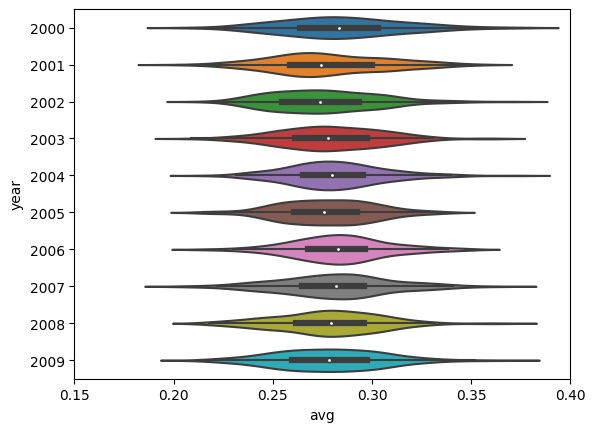

In [35]:
mask = (sns_df['year'] >= 2000) & (sns_df['year'] < 2010)
fig, ax = plt.subplots()
sns.violinplot(
    data=sns_df[mask], observed=True,
    ax=ax, x='avg', y='year', order=sns_df.loc[mask, 'year'].unique()
)
ax.set_xlim(.15, .4)
plt.show()

d:\Python3.11.1\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


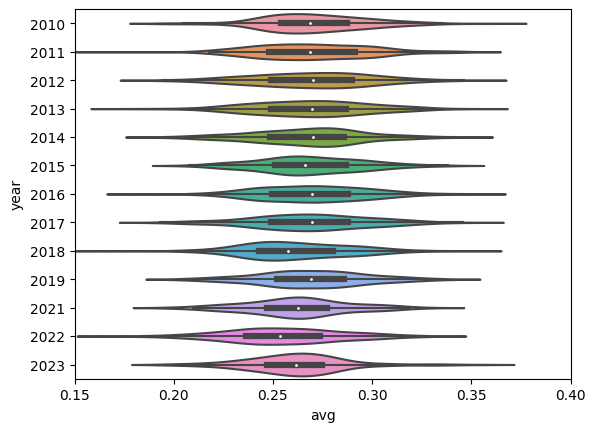

In [36]:
mask = sns_df["year"] >= 2010
fig, ax = plt.subplots()
sns.violinplot(
    data=sns_df[mask],
    ax=ax,
    x="avg",
    y="year",
    order=sns_df.loc[mask, "year"].unique(),
)
ax.set_xlim(0.15, 0.4)
plt.show()

为了更好地比较不同年份的巅峰表现，我们可以使用一种技术来规范每个赛季的数据。我们不会考虑绝对击球率（如 .250），而是考虑击球手的表现在一个赛季内超出正常水平的程度。

更具体地说，我们可以使用 Z 分数标准化，其数学表示如下：

$$z=\frac{x-\mu}{\sigma}$$

In [39]:
def normalize(ser: pd.Series) -> pd.Series:
    return (ser - ser.mean()) / ser.std()


(
    averages.assign(
        normalized_avg=averages.groupby('year').transform(normalize)
    )
    .groupby('year').agg(
        league_mean_avg=pd.NamedAgg('avg', 'mean'),
        league_max_avg=pd.NamedAgg('avg', 'max'),
        batting_champion=pd.NamedAgg('avg', 'idxmax'),
        max_normalized_avg=pd.NamedAgg('normalized_avg', 'max')
    )
    .sort_values(by='max_normalized_avg', ascending=False)
).head()

,league_mean_avg,league_max_avg,batting_champion,max_normalized_avg
year,,,,
2023,0.261457,0.353659,"(2023, arral001)",3.714121
2004,0.281307,0.372159,"(2004, suzui001)",3.699129
2002,0.275713,0.369727,"(2002, bondb001)",3.553521
2010,0.271227,0.359073,"(2010, hamij003)",3.379203
2008,0.277991,0.364465,"(2008, jonec004)",3.320429
